# Tres algoritmos en Colab · resuelto y explicado

Este notebook trae **el código completo** de la actividad de los tres algoritmos (árbol de
decisión, reglas de asociación y regresión lineal), en el mismo orden del enunciado: celda 0,
A1–A4, B1–B4 y C1–C2. En cada tarea se explica qué hace cada línea:

| Celda | Qué trae |
|---|---|
| 🔎 **Cómo se resuelve** | Qué se pide, la idea de la solución y qué hace **cada línea** del código |
| **Código** | La solución, ya ejecutada |
| ✔ **Verificación** | Compara con el **Debe salir** del enunciado |
| 🧭 **Qué debe salir** | Las líneas ✅ esperadas y qué hacer si a ustedes les sale otra cosa |
| ✍️ **Preguntas y bitácora** | **En blanco: son de ustedes.** El código no interpreta por ustedes |

**Cómo usarlo:** ábranlo al lado de su propio notebook y comparen tarea por tarea. Lo que más pesa
en la lista de cotejo es la **interpretación**: las preguntas PA1–PC4, la tabla de la Parte D y las
bitácoras, escritas con sus palabras.

**Cómo abrirlo en Colab:** `colab.research.google.com` → `Archivo → Subir notebook` → elijan este
archivo. Para ejecutarlo desde cero: `Entorno de ejecución → Reiniciar y ejecutar todo`. La
celda 0 tarda cerca de medio minuto. Al final, `resumen()` debe mostrar **22 de 22 verificaciones
en ✅**.

## Celda 0 · Configuración, datos y limpieza

### 🔎 Qué hace la celda 0

Es la celda que se copia **tal cual** desde el enunciado. Carga los datos, repite en pocas líneas la limpieza del trabajo anterior y arma la tabla `modelo`. Aquí trae además `verificar()` y `resumen()`.

| Código | Qué hace |
|---|---|
| `%pip install -q mlxtend==0.23.4` | instala **mlxtend**, la librería de Apriori, en la versión fija del curso. Colab ya trae pandas, matplotlib y scikit-learn. `-q` = sin tanto texto |
| `pd.read_csv(RUTA_DATOS + "...")` | lee los cuatro CSV crudos desde el repositorio público: `clientes`, `boletas`, `detalle` (las líneas de cada boleta) y `productos` |
| `str.strip().str.title().replace(tildes)` | la limpieza de comunas del trabajo anterior (Sección 1), en una sola línea |
| `.fillna("Sin dato") / .fillna(...mode()[0])` | los faltantes (Sección 2): comuna declarada como «Sin dato», canal de alta con la moda |
| `drop_duplicates(subset="rut_norm", keep="first")` | los clientes duplicados por RUT normalizado (Sección 3 y G1) |
| `imposible = nac.isna() ...` | las fechas de nacimiento imposibles (G3): su edad queda vacía |
| `boletas[boletas.total >= 0]` | fuera las devoluciones (Sección 4) |
| `boletas.fecha_hora.dt.year >= 2024` | fuera las boletas con la fecha falsa 1970-01-01 |
| `detalle[detalle.id_boleta.isin(...) & (detalle.cantidad > 0)]` | el detalle queda solo con líneas de boletas válidas y cantidades positivas |
| `def tramo(edad):` | una función que convierte la edad en un tramo; sin edad → «Sin dato» |
| `modelo = pd.DataFrame({...})` | la tabla de modelado de la Parte III: una fila por cliente, cuatro atributos y la clase `fuga` (sin compras desde el 01/05/2025) |
| `def verificar(...) / def resumen()` | las mismas funciones de control del trabajo anterior: ✅ o ❌ contra el número esperado |

In [1]:
# ============================================================
#  CELDA 0 · ejecutar primero, siempre
# ============================================================
%pip install -q mlxtend==0.23.4

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Los CSV crudos de siempre, desde internet
RUTA_DATOS = "https://raw.githubusercontent.com/de-mag-ia/diguillin-datos/main/crudo/"
clientes = pd.read_csv(RUTA_DATOS + "clientes.csv")
boletas = pd.read_csv(RUTA_DATOS + "boletas.csv")
detalle = pd.read_csv(RUTA_DATOS + "detalle_boletas.csv")
productos = pd.read_csv(RUTA_DATOS + "productos.csv")

# ── La limpieza del trabajo anterior, en pocas líneas ──────────────────────────
tildes = {"Chillan": "Chillán", "Chillan Viejo": "Chillán Viejo", "Quillon": "Quillón"}
clientes["comuna"] = clientes.comuna.str.strip().str.title().replace(tildes).fillna("Sin dato")
clientes["canal_alta"] = clientes.canal_alta.fillna(clientes.canal_alta.mode()[0])
clientes["rut_norm"] = (clientes.rut.str.replace(".", "", regex=False)
                                    .str.replace("-", "", regex=False).str.upper())
clientes = clientes.drop_duplicates(subset="rut_norm", keep="first").copy()
nac = pd.to_datetime(clientes.fecha_nacimiento, errors="coerce")
imposible = nac.isna() | (nac.dt.year < 1920) | (nac > pd.Timestamp("2025-06-30"))
clientes["edad"] = (2025 - nac.dt.year).where(~imposible)

boletas = boletas.drop_duplicates(subset="id_boleta", keep="first")
boletas = boletas[boletas.total >= 0].copy()                  # fuera las devoluciones
boletas["fecha_hora"] = pd.to_datetime(boletas.fecha_hora)
boletas = boletas[boletas.fecha_hora.dt.year >= 2024].copy()  # fuera la fecha falsa 1970-01-01
detalle = detalle[detalle.id_boleta.isin(boletas.id_boleta) & (detalle.cantidad > 0)]

# ── La tabla de modelado del trabajo anterior (Parte III): una fila por cliente ──
LOCAL = {"Chillán", "Chillán Viejo", "San Carlos", "Bulnes", "Coihueco", "Quillón"}
ultima = boletas.dropna(subset=["id_cliente"]).groupby("id_cliente").fecha_hora.max()

def tramo(edad):
    if pd.isna(edad):
        return "Sin dato"
    if edad <= 29:
        return "18-29"
    if edad <= 44:
        return "30-44"
    if edad <= 59:
        return "45-59"
    return "60+"

si_no = {True: "Sí", False: "No"}
modelo = pd.DataFrame({
    "tramo":       clientes.edad.map(tramo),
    "promos":      clientes.acepta_promociones.map(si_no),
    "local_cerca": clientes.comuna.isin(LOCAL).map(si_no),
    "canal_alta":  clientes.canal_alta,
    "fuga":        (clientes.id_cliente.map(ultima) < pd.Timestamp("2025-05-01")).map(si_no),
})

# Los números que deben salir en cada paso
ESPERADO = {
    'clientes_limpios': 1200,
    'boletas_limpias': 57372,
    'modelo_filas': 1200,
    'modelo_fugados': 291,
    'columnas_X': 13,
    'filas_entrenamiento': 840,
    'filas_prueba': 360,
    'aciertos_arbol': 269,
    'aciertos_zeror_prueba': 273,
    'fugados_en_prueba': 87,
    'fugados_detectados': 11,
    'fugados_detectados_bal': 71,
    'boletas_en_cesta': 57371,
    'productos_en_cesta': 95,
    'n_frecuentes': 478,
    'n_reglas': 234,
    'confianza_levadura_harina': 0.82,
    'pendiente_pesos_por_item': 3660,
    'r2_simple': 0.88,
    'dias_con_venta': 365,
    'efecto_quincena': 37,
    'r2_demanda': 0.37,
}
_resultados = {}

def verificar(clave, valor):
    """Compara su resultado con el esperado e imprime ✅ o ❌."""
    esperado = ESPERADO[clave]
    if hasattr(valor, "item"):
        valor = valor.item()
    ok = (valor == esperado)
    _resultados[clave] = ok
    print(("✅ " if ok else "❌ ") + f"{clave} = {valor}" + ("" if ok else f"   (debía salir {esperado})"))

def resumen():
    ok = sum(_resultados.values())
    print(f"{ok} de {len(ESPERADO)} verificaciones en ✅")
    pendientes = [k for k in ESPERADO if not _resultados.get(k)]
    if pendientes:
        print("Pendientes o con ❌:", ", ".join(pendientes))

verificar("clientes_limpios", len(clientes))
verificar("boletas_limpias", len(boletas))
verificar("modelo_filas", len(modelo))
verificar("modelo_fugados", (modelo.fuga == "Sí").sum())

Note: you may need to restart the kernel to use updated packages.


✅ clientes_limpios = 1200
✅ boletas_limpias = 57372
✅ modelo_filas = 1200
✅ modelo_fugados = 291


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ clientes_limpios = 1200
✅ boletas_limpias = 57372
✅ modelo_filas = 1200
✅ modelo_fugados = 291
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| Aparece *Note: you may need to restart the kernel…* | es normal: no hay que reiniciar |
| `ModuleNotFoundError: No module named 'mlxtend'` | la instalación no terminó: ejecute la celda 0 de nuevo |
| Error de conexión al leer un CSV | falló la descarga: ejecute la celda 0 de nuevo |

---
# Parte A · Árbol de decisión
*Semana 7 de la planificación.* ¿Qué clientes se fugan? El mismo problema de ZeroR y OneR, con la misma tabla `modelo` (1.200 clientes, 4 atributos). La diferencia: el árbol puede **combinar** atributos.

## A1 · Preparar los datos para el árbol

**Qué se pide.** Un árbol de scikit-learn solo trabaja con números. Transforme los cuatro atributos de `modelo` (todo menos `fuga`) en columnas de ceros y unos, una por cada valor posible, y guárdelas en `X`. La clase `fuga` va en `y`.

### 🔎 Cómo se resuelve

**La idea.** Un árbol de scikit-learn hace preguntas del tipo *¿columna ≤ 0,5?*: necesita números. La **codificación one-hot** convierte cada valor de texto en su propia columna de ceros y unos (`tramo_60+`, `promos_Sí`, …). La clase `fuga` queda aparte, en `y`.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `atributos = [...]` | la lista de las columnas que el árbol puede usar (todas menos `fuga`) |
| `pd.get_dummies(modelo[atributos])` | una columna por cada valor de cada atributo: 5 tramos + 2 promos + 2 local_cerca + 4 canales = 13. Salen como `True`/`False`, que valen 1/0 |
| `y = modelo.fuga` | lo que se quiere predecir: «Sí» o «No» |
| `X.shape` | (filas, columnas): (1200, 13) |
| `X.head()` | muestra las 5 primeras filas para **mirar** cómo quedó |

In [2]:
# A1 · Preparar los datos para el árbol

atributos = ["tramo", "promos", "local_cerca", "canal_alta"]
X = pd.get_dummies(modelo[atributos])    # una columna 0/1 por cada valor de cada atributo
y = modelo.fuga                          # la clase que se quiere predecir
print(X.shape)
X.head()

(1200, 13)


,tramo_18-29,tramo_30-44,tramo_45-59,tramo_60+,tramo_Sin dato,promos_No,promos_Sí,local_cerca_No,local_cerca_Sí,canal_alta_App móvil,canal_alta_Caja,canal_alta_Campaña en local,canal_alta_Sitio web
0,False,False,True,False,False,False,True,True,False,False,False,True,False
1,True,False,False,False,False,False,True,False,True,True,False,False,False
2,False,True,False,False,False,True,False,False,True,False,True,False,False
3,False,True,False,False,False,False,True,False,True,False,True,False,False
4,False,False,True,False,False,False,True,True,False,False,False,False,True


In [3]:
# ✔ Verificación · A1
verificar("columnas_X", X.shape[1])

✅ columnas_X = 13


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ columnas_X = 13
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| Salen **15** columnas | se codificó `modelo` completo, con `fuga` adentro (`fuga_No` y `fuga_Sí`). La clase nunca va en `X`: el árbol estaría mirando la respuesta |

## A2 · Separar entrenamiento y prueba

**Qué se pide.** Separe los clientes en dos grupos: el **70 % para entrenar** el árbol y el **30 % para probarlo** con clientes que no vio. Use la **semilla aleatoria 2026** y mantenga en los dos grupos la misma proporción de fugados (separación **estratificada**). Llame a los cuatro resultados `X_ent`, `X_pru`, `y_ent` e `y_pru`.

### 🔎 Cómo se resuelve

**La idea.** Un modelo se evalúa con datos **que no vio**. Se separa el 70 % para entrenar y el 30 % para probar. La semilla (`random_state`) hace que la separación al azar sea siempre la misma, y `stratify` mantiene la proporción de fugados en las dos partes.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `from sklearn.model_selection import train_test_split` | trae la función desde scikit-learn |
| `test_size=0.3` | el 30 % va a prueba |
| `random_state=2026` | la semilla: con la misma semilla, la misma separación |
| `stratify=y` | separación **estratificada**: el 24 % de fugados en ambas partes |
| `X_ent, X_pru, y_ent, y_pru = ...` | devuelve **cuatro** tablas, siempre en ese orden |

In [4]:
# A2 · Separar entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.3, random_state=2026, stratify=y)
print("entrenamiento:", len(X_ent), "  prueba:", len(X_pru))

entrenamiento: 840   prueba: 360


In [5]:
# ✔ Verificación · A2
verificar("filas_entrenamiento", len(X_ent))
verificar("filas_prueba", len(X_pru))

✅ filas_entrenamiento = 840
✅ filas_prueba = 360


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ filas_entrenamiento = 840
✅ filas_prueba = 360
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| 840 / 360 en ✅, pero después A3 y A4 dan ❌ | faltó `stratify=y` o la semilla no es 2026: los tamaños salen iguales, pero los clientes son otros |
| `ValueError: not enough values to unpack` | se asignaron menos de cuatro variables a la izquierda del `=` |

## A3 · Entrenar el árbol, dibujarlo y compararlo con ZeroR

**Qué se pide.** Cree un árbol de decisión para clasificación con **profundidad máxima 3** y **semilla 2026**. Entrénelo con los datos de entrenamiento y úselo para predecir los de prueba. Cuente cuántos clientes de prueba **acierta**, y compárelo con ZeroR (responder siempre «No») sobre los mismos clientes de prueba. Por último, **dibuje el árbol**.

### 🔎 Cómo se resuelve

**La idea.** Se crea el árbol con sus parámetros, se **entrena** con `.fit` (aprende las preguntas) y se **prueba** con `.predict` sobre clientes que no vio. El acierto se compara con ZeroR en la misma prueba: si no le gana, el modelo no aporta acierto.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `DecisionTreeClassifier(max_depth=3, random_state=2026)` | un árbol de clasificación de hasta 3 preguntas seguidas |
| `arbol.fit(X_ent, y_ent)` | **entrena**: busca las mejores preguntas con el 70 % |
| `pred = arbol.predict(X_pru)` | una predicción («Sí»/«No») para cada cliente de prueba |
| `(pred == y_pru).sum()` | compara predicción con realidad, fila a fila, y cuenta los `True`: los aciertos |
| `(y_pru == "No").sum()` | ZeroR responde siempre «No»: acierta tantos como no fugados haya en prueba |
| `plt.figure(figsize=(18, 7))` | un lienzo ancho, para que el árbol se lea |
| `plot_tree(arbol, feature_names=..., class_names=..., filled=True)` | dibuja el árbol con los nombres de las columnas y de las clases, coloreado según la clase |

árbol: 269 de 360   ·  ZeroR: 273


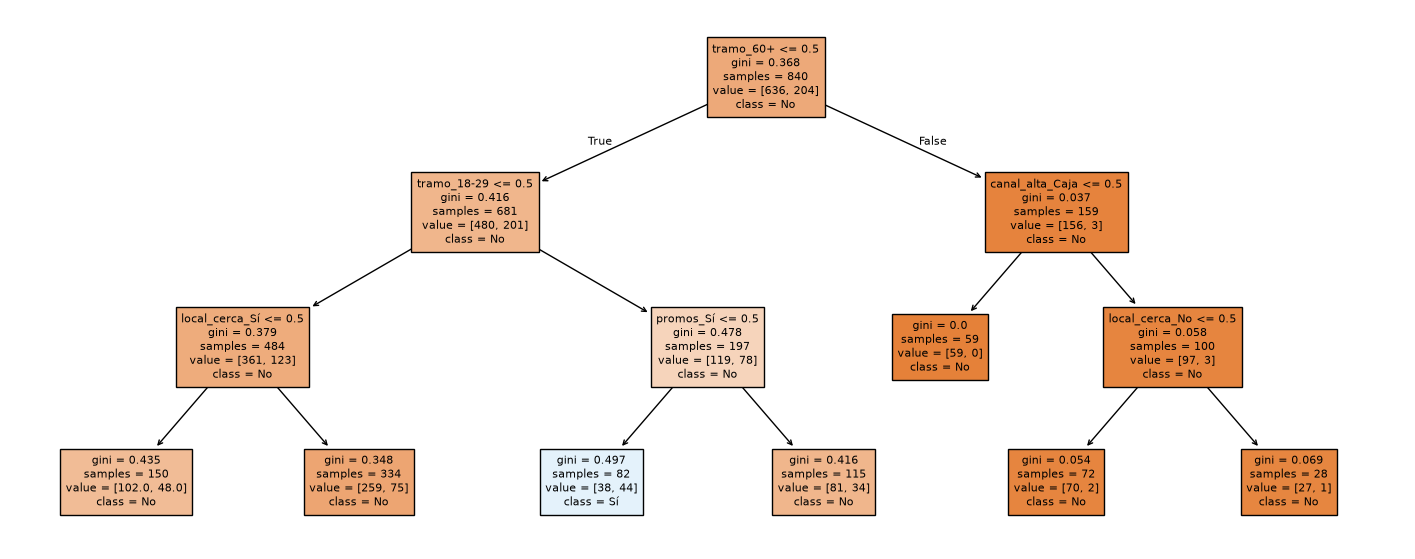

In [6]:
# A3 · Entrenar el árbol, dibujarlo y compararlo con ZeroR

from sklearn.tree import DecisionTreeClassifier, plot_tree

arbol = DecisionTreeClassifier(max_depth=3, random_state=2026)
arbol.fit(X_ent, y_ent)                  # aprende con el 70 %
pred = arbol.predict(X_pru)              # predice el 30 % que no vio

aciertos_arbol = (pred == y_pru).sum()
aciertos_zeror = (y_pru == "No").sum()   # ZeroR: responde siempre "No"
print("árbol:", aciertos_arbol, "de", len(y_pru), "  ·  ZeroR:", aciertos_zeror)

plt.figure(figsize=(18, 7))
plot_tree(arbol, feature_names=list(X.columns), class_names=list(arbol.classes_),
          filled=True, fontsize=8)
plt.show()

In [7]:
# ✔ Verificación · A3
verificar("aciertos_arbol", aciertos_arbol)
verificar("aciertos_zeror_prueba", aciertos_zeror)

✅ aciertos_arbol = 269
✅ aciertos_zeror_prueba = 273


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ aciertos_arbol = 269
✅ aciertos_zeror_prueba = 273
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| `ValueError: could not convert string to float` | se entrenó con `modelo` en vez de `X`: el árbol recibió texto |
| Aciertos distintos de los esperados | otra profundidad u otra semilla: cualquier cambio de parámetros mueve los resultados |
| El dibujo sale ilegible | falta `plt.figure(figsize=(18, 7))` antes de `plot_tree` |

## A4 · ¿Cuántos fugados detecta? Y con clases balanceadas

**Qué se pide.** El acierto no lo dice todo. Cuente cuántos **fugados de prueba** detectó el árbol (el árbol dijo «Sí» y el cliente era «Sí»). Después entrene un **segundo árbol igual, pero que compense el desbalance de clases**, y cuente cuántos fugados detecta. Muestre también su **matriz de confusión**.

### 🔎 Cómo se resuelve

**La idea.** El acierto total esconde lo importante: **¿a cuántos fugados encuentra?** Un fugado detectado cumple dos condiciones a la vez: el árbol dijo «Sí» **y** era «Sí». Después se entrena un árbol que da más peso a la clase minoritaria y se comparan.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `(y_pru == "Sí").sum()` | cuántos fugados hay en prueba |
| `(pred == "Sí") & (y_pru == "Sí")` | `&` = **y**: las dos condiciones a la vez. Cada condición va entre paréntesis |
| `class_weight="balanced"` | al entrenar, cada fugado pesa más (hay menos): el árbol se arriesga más a decir «Sí» |
| `pd.crosstab(y_pru, pred_bal, rownames=["real"], colnames=["predicho"])` | la **matriz de confusión**: filas = lo real, columnas = lo que predijo |

In [8]:
# A4 · ¿Cuántos fugados detecta? Y con clases balanceadas

fugados_en_prueba = (y_pru == "Sí").sum()
fugados_detectados = ((pred == "Sí") & (y_pru == "Sí")).sum()

arbol_bal = DecisionTreeClassifier(max_depth=3, random_state=2026, class_weight="balanced")
arbol_bal.fit(X_ent, y_ent)
pred_bal = arbol_bal.predict(X_pru)
fugados_detectados_bal = ((pred_bal == "Sí") & (y_pru == "Sí")).sum()

print("fugados en prueba:", fugados_en_prueba)
print("detectados · árbol normal:", fugados_detectados, "  ·  balanceado:", fugados_detectados_bal)
print("aciertos totales del balanceado:", (pred_bal == y_pru).sum(), "de", len(y_pru))
pd.crosstab(y_pru, pred_bal, rownames=["real"], colnames=["predicho"])

fugados en prueba: 87
detectados · árbol normal: 11   ·  balanceado: 71
aciertos totales del balanceado: 195 de 360


predicho,No,Sí
real,,
No,124,149
Sí,16,71


In [9]:
# ✔ Verificación · A4
verificar("fugados_en_prueba", fugados_en_prueba)
verificar("fugados_detectados", fugados_detectados)
verificar("fugados_detectados_bal", fugados_detectados_bal)

✅ fugados_en_prueba = 87
✅ fugados_detectados = 11
✅ fugados_detectados_bal = 71


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ fugados_en_prueba = 87
✅ fugados_detectados = 11
✅ fugados_detectados_bal = 71
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| `ValueError: The truth value of a Series is ambiguous` | se usó `and` en vez de `&`. Con columnas de pandas se usa `&` (y), la barra vertical (o) y `~` (no) |
| `TypeError` con `&` | faltan los paréntesis alrededor de cada condición |

### Preguntas de interpretación · Parte A · Árbol de decisión

Una respuesta por pregunta, con sus palabras y **con los números** de su notebook.

**PA1.** Mire el árbol dibujado: ¿qué camino lleva a una hoja que predice **"Sí"**? Escríbalo como regla *si … y … entonces …* y diga si tiene sentido para el negocio.

> ✍️ Su respuesta: …

**PA2.** El árbol encontró esa regla, pero no le gana a ZeroR en aciertos. ¿Por qué?

> ✍️ Su respuesta: …

**PA3.** ¿Qué cambió al compensar el desbalance de clases (A4)? ¿Qué árbol preferiría la gerencia para un plan de retención, y qué precio se paga?

> ✍️ Su respuesta: …

**PA4.** ¿Qué puede hacer un árbol que OneR no podía?

> ✍️ Su respuesta: …

> ✍️ **Bitácora · Parte A · Árbol de decisión**
>
> - **Qué hicimos y qué decidimos:** …
> - **Fuente consultada** (documentación, compañeros, IA — cuál y para qué): …
> - **Qué no funcionó a la primera:** …

---
# Parte B · Reglas de asociación (Apriori)
*Semana 8 de la planificación.* ¿Qué productos se compran juntos? Sobre las boletas de venta y su detalle. No hay clase que predecir: se buscan **patrones** en las canastas.

## B1 · La canasta: una fila por boleta, una columna por producto

**Qué se pide.** Apriori necesita saber qué productos tiene cada boleta. Arme una tabla `cesta` con **una fila por boleta** y **una columna por producto** (con su nombre), que diga verdadero si la boleta tiene ese producto y falso si no.

### 🔎 Cómo se resuelve

**La idea.** Apriori trabaja con **canastas**: una fila por boleta y una columna por producto, verdadero si la boleta lo tiene. El detalle trae el `id_producto`; para leer las reglas con nombres, primero se trae el nombre desde `productos`.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `detalle.merge(productos[[...]], on="id_producto")` | el BUSCARV de pandas: agrega a cada línea del detalle el nombre de su producto |
| `pd.crosstab(con_nombre.id_boleta, con_nombre.nombre_producto)` | una tabla de doble entrada que **cuenta** cuántas veces aparece cada producto en cada boleta |
| `... > 0` | convierte los conteos en `True`/`False`: está o no está |
| `cesta.iloc[:5, :6]` | las primeras 5 filas y 6 columnas, para mirar |

In [10]:
# B1 · La canasta: una fila por boleta, una columna por producto

con_nombre = detalle.merge(productos[["id_producto", "nombre_producto"]], on="id_producto")
cesta = pd.crosstab(con_nombre.id_boleta, con_nombre.nombre_producto) > 0
print(cesta.shape)
cesta.iloc[:5, :6]

(57371, 95)


nombre_producto,Aceite vegetal 900ml,Agua mineral 1.6L,Alimento gato 3kg,Alimento perro 1.5kg,Alimento perro 10kg,Aliño completo 100g
id_boleta,,,,,,
B0000001,False,True,True,False,True,True
B0000002,False,False,False,False,False,False
B0000003,False,False,False,False,False,False
B0000004,False,False,False,False,False,False
B0000005,False,True,False,True,False,False


In [11]:
# ✔ Verificación · B1
verificar("boletas_en_cesta", cesta.shape[0])
verificar("productos_en_cesta", cesta.shape[1])

✅ boletas_en_cesta = 57371
✅ productos_en_cesta = 95


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ boletas_en_cesta = 57371
✅ productos_en_cesta = 95
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| Las columnas son números, no nombres | faltó el `merge`: la tabla quedó por `id_producto`, y en B4 no se podrá buscar «Levadura seca 10g» |
| 57.371 filas y no 57.372 | es lo esperado: una boleta válida no tiene ninguna línea de detalle válida |

## B2 · Los conjuntos frecuentes (Apriori)

**Qué se pide.** Busque los productos y los **pares de productos** que aparecen en al menos el **2 % de las boletas** (soporte mínimo 2 %). Guárdelos en `frecuentes`, con los nombres de los productos (no sus números de columna).

### 🔎 Cómo se resuelve

**La idea.** Apriori recorre la canasta y se queda con los productos y pares que aparecen en al menos el 2 % de las boletas (el **soporte mínimo**). `max_len=2` limita a pares, para que sea rápido y legible.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `from mlxtend.frequent_patterns import apriori, association_rules` | las dos funciones de mlxtend: la de B2 y la de B3 |
| `min_support=0.02` | soporte mínimo: el 2 % de las boletas |
| `use_colnames=True` | los conjuntos se muestran con el **nombre** del producto, no con el número de columna |
| `max_len=2` | hasta pares de productos |
| `frecuentes.sort_values("support", ascending=False).head(10)` | los 10 más frecuentes, de mayor a menor |

In [12]:
# B2 · Los conjuntos frecuentes (Apriori)

from mlxtend.frequent_patterns import apriori, association_rules

frecuentes = apriori(cesta, min_support=0.02, use_colnames=True, max_len=2)
print(len(frecuentes), "conjuntos frecuentes")
frecuentes.sort_values("support", ascending=False).head(10)

478 conjuntos frecuentes


,support,itemsets
62,0.222517,frozenset({Pan amasado kg})
10,0.210402,frozenset({Bebida cola 3L})
20,0.200798,frozenset({Cerveza lata 470cc})
46,0.194645,frozenset({Leche entera 1L})
86,0.179586,frozenset({Tomate kg})
57,0.176988,frozenset({Marraqueta kg})
61,0.174426,frozenset({Palta kg})
52,0.168744,frozenset({Longaniza de Chillán kg})
37,0.145910,frozenset({Hallulla kg})
36,0.131582,frozenset({Galletas surtidas 400g})


In [13]:
# ✔ Verificación · B2
verificar("n_frecuentes", len(frecuentes))

✅ n_frecuentes = 478


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ n_frecuentes = 478
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| `ValueError: The allowed values for a DataFrame are True, False, 0, 1` | falta el `> 0` en B1: la canasta tiene conteos (2, 3…) y no verdadero/falso |
| Los conjuntos se ven como `frozenset({12, 40})` | falta `use_colnames=True` |

## B3 · Las reglas: si compra A, también compra B

**Qué se pide.** A partir de `frecuentes`, genere las **reglas de asociación** que tengan **lift mayor a 1,5** y ordénelas de mayor a menor lift. Agregue dos columnas de texto legible: `si_compra` (el antecedente) y `tambien_compra` (el consecuente).

### 🔎 Cómo se resuelve

**La idea.** De cada par frecuente salen dos reglas (A → B y B → A), cada una con su soporte, confianza y lift. Se dejan las de **lift > 1,5** y se ordenan de mayor a menor. Los productos vienen como conjuntos de Python (`frozenset`): se pasan a texto para leerlos.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `association_rules(frecuentes, num_itemsets=len(cesta), ...)` | arma las reglas; `num_itemsets` es la cantidad total de boletas (obligatorio en mlxtend 0.23) |
| `metric="lift", min_threshold=1.5` | filtra por lift mayor a 1,5 |
| `reglas.antecedents.apply(lambda s: ", ".join(s))` | a cada conjunto le aplica una función que une sus elementos con «, »: `frozenset({'Levadura seca 10g'})` → `Levadura seca 10g` |
| `sort_values("lift", ascending=False)` | de mayor a menor lift |
| `[["si_compra", ...]].round(3).head(12)` | las columnas legibles, con 3 decimales |

In [14]:
# B3 · Las reglas: si compra A, también compra B

reglas = association_rules(frecuentes, num_itemsets=len(cesta),
                           metric="lift", min_threshold=1.5)
reglas["si_compra"] = reglas.antecedents.apply(lambda s: ", ".join(s))
reglas["tambien_compra"] = reglas.consequents.apply(lambda s: ", ".join(s))
reglas = reglas.sort_values("lift", ascending=False)
print(len(reglas), "reglas")
reglas[["si_compra", "tambien_compra", "support", "confidence", "lift"]].round(3).head(12)

234 reglas


,si_compra,tambien_compra,support,confidence,lift
137,Harina sin polvos 1kg,Levadura seca 10g,0.024,0.262,9.008
136,Levadura seca 10g,Harina sin polvos 1kg,0.024,0.824,9.008
180,Levadura seca 10g,Mantequilla 250g,0.023,0.805,8.602
181,Mantequilla 250g,Levadura seca 10g,0.023,0.250,8.602
147,Levadura seca 10g,Huevos 12un,0.024,0.812,7.685
146,Huevos 12un,Levadura seca 10g,0.024,0.224,7.685
221,Pañales talla M 40un,Toallitas húmedas 80un,0.053,0.821,6.790
220,Toallitas húmedas 80un,Pañales talla M 40un,0.053,0.438,6.790
219,Pañales talla G 36un,Toallitas húmedas 80un,0.041,0.813,6.724
218,Toallitas húmedas 80un,Pañales talla G 36un,0.041,0.343,6.724


In [15]:
# ✔ Verificación · B3
verificar("n_reglas", len(reglas))

✅ n_reglas = 234


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ n_reglas = 234
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| `TypeError: association_rules() missing 1 required positional argument: 'num_itemsets'` | falta `num_itemsets=len(cesta)` |
| Otra cantidad de reglas | se instaló otra versión de mlxtend. La celda 0 fija la 0.23.4: no la cambie |

## B4 · Leer una regla: levadura → harina

**Qué se pide.** Busque en sus reglas la regla *si compra `Levadura seca 10g` → también compra `Harina sin polvos 1kg`* y guarde su **confianza redondeada a 2 decimales**. Busque también la regla al revés (harina → levadura) y compárelas.

### 🔎 Cómo se resuelve

**La idea.** Leer una regla es **filtrar** la tabla de reglas con dos condiciones: el antecedente y el consecuente. Se mira también la regla al revés, para comparar confianza y lift.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `reglas[(reglas.si_compra == "...") & (reglas.tambien_compra == "...")]` | las filas que cumplen las dos condiciones (debe quedar una) |
| `ida.confidence.iloc[0]` | `.iloc[0]` toma el valor de la primera (y única) fila |
| `round(x, 2)` | redondea a 2 decimales |
| `.to_dict("records")` | convierte la fila en un diccionario, para imprimirla en una línea |

In [16]:
# B4 · Leer una regla: levadura → harina

ida = reglas[(reglas.si_compra == "Levadura seca 10g")
             & (reglas.tambien_compra == "Harina sin polvos 1kg")]
vuelta = reglas[(reglas.si_compra == "Harina sin polvos 1kg")
                & (reglas.tambien_compra == "Levadura seca 10g")]
confianza_levadura = round(ida.confidence.iloc[0], 2)
print("levadura → harina:", ida[["support", "confidence", "lift"]].round(3).to_dict("records"))
print("harina → levadura:", vuelta[["support", "confidence", "lift"]].round(3).to_dict("records"))

levadura → harina: [{'support': 0.024, 'confidence': 0.824, 'lift': 9.008}]
harina → levadura: [{'support': 0.024, 'confidence': 0.262, 'lift': 9.008}]


In [17]:
# ✔ Verificación · B4
verificar("confianza_levadura_harina", confianza_levadura)

✅ confianza_levadura_harina = 0.82


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ confianza_levadura_harina = 0.82
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| `IndexError: single positional indexer is out-of-bounds` | el filtro quedó vacío: el nombre del producto está mal escrito. Tiene que ser exacto, con «10g» y «1kg» |

### Preguntas de interpretación · Parte B · Reglas de asociación (Apriori)

Una respuesta por pregunta, con sus palabras y **con los números** de su notebook.

**PB1.** Explique **soporte**, **confianza** y **lift** con los números de la regla levadura → harina.

> ✍️ Su respuesta: …

**PB2.** ¿Por qué levadura → harina y harina → levadura tienen el mismo lift pero distinta confianza?

> ✍️ Su respuesta: …

**PB3.** Elija dos reglas del top y proponga una acción concreta para el supermercado.

> ✍️ Su respuesta: …

**PB4.** ¿Una regla fuerte prueba que comprar A **causa** comprar B?

> ✍️ Su respuesta: …

> ✍️ **Bitácora · Parte B · Reglas de asociación (Apriori)**
>
> - **Qué hicimos y qué decidimos:** …
> - **Fuente consultada** (documentación, compañeros, IA — cuál y para qué): …
> - **Qué no funcionó a la primera:** …

---
# Parte C · Regresión lineal
*Semana 9 de la planificación.* ¿Cuánto se vende? Ahora lo que se predice es un **número**: el total de una boleta y la cantidad de boletas de un día.

## C1 · Regresión simple: el total de la boleta según los ítems

**Qué se pide.** Ajuste una **regresión lineal simple** que explique el `total` de cada boleta a partir de su número de ítems (`n_items`). Informe la **pendiente** (redondeada, en pesos) y el **R²** (2 decimales). Grafique los puntos y la recta.

### 🔎 Cómo se resuelve

**La idea.** La regresión busca la recta *total = a + b · n_items* que pasa más cerca de todas las boletas. `b` (la **pendiente**) es lo que suma cada ítem en pesos, y el **R²** dice qué parte de la variación del total explica el número de ítems.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `LinearRegression().fit(boletas[["n_items"]], boletas.total)` | entrena la recta. La `X` va con **doble corchete** (una tabla), la `y` con uno (una columna) |
| `recta.coef_[0]` | la pendiente: pesos por ítem |
| `recta.intercept_` | el intercepto: dónde corta la recta cuando hay 0 ítems |
| `recta.score(X, y)` | el R² del modelo |
| `recta.predict(pd.DataFrame({"n_items": [20]}))` | la predicción para una boleta de 20 ítems |
| `plt.scatter(..., s=2, alpha=0.15)` | un punto por boleta, chico y transparente, porque son 57 mil |
| `plt.plot(xs.n_items, recta.predict(xs), color="red")` | la recta encima de los puntos |

total ≈ -2471 + 3660 × n_items   ·   R² = 0.88
una boleta de 20 ítems: 70726 pesos


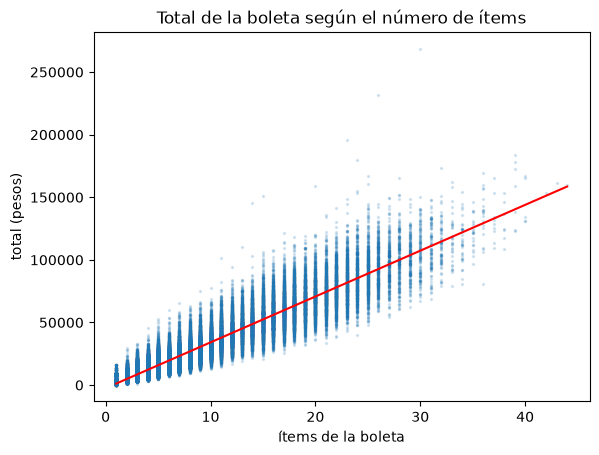

In [18]:
# C1 · Regresión simple: el total de la boleta según los ítems

from sklearn.linear_model import LinearRegression

recta = LinearRegression().fit(boletas[["n_items"]], boletas.total)
pendiente = round(recta.coef_[0])
r2_simple = round(recta.score(boletas[["n_items"]], boletas.total), 2)
print("total ≈", round(recta.intercept_), "+", pendiente, "× n_items   ·   R² =", r2_simple)
print("una boleta de 20 ítems:", round(recta.predict(pd.DataFrame({"n_items": [20]}))[0]), "pesos")

plt.scatter(boletas.n_items, boletas.total, s=2, alpha=0.15)
xs = pd.DataFrame({"n_items": range(1, boletas.n_items.max() + 1)})
plt.plot(xs.n_items, recta.predict(xs), color="red")
plt.xlabel("ítems de la boleta")
plt.ylabel("total (pesos)")
plt.title("Total de la boleta según el número de ítems")
plt.show()

In [19]:
# ✔ Verificación · C1
verificar("pendiente_pesos_por_item", pendiente)
verificar("r2_simple", r2_simple)

✅ pendiente_pesos_por_item = 3660
✅ r2_simple = 0.88


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ pendiente_pesos_por_item = 3660
✅ r2_simple = 0.88
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| `ValueError: Expected 2D array, got 1D array` | la `X` se pasó con un solo corchete (`boletas.n_items`). Tiene que ser `boletas[["n_items"]]` |

## C2 · Regresión múltiple: la demanda de cada día

**Qué se pide.** Cuente las **boletas de cada día** del año y explíquelas con una **regresión lineal múltiple** con dos variables de ceros y unos: `finde` (1 si es sábado o domingo) y `quincena` (1 si es día 1 a 5 o 15 a 20 del mes, cuando se pagan sueldos). Informe el **efecto de la quincena** (su coeficiente, redondeado) y el **R²** (2 decimales), y prediga cuántas boletas tendría un sábado de quincena.

### 🔎 Cómo se resuelve

**La idea.** Primero se cuenta cuántas boletas hubo **cada día**. Después se explica esa cantidad con dos variables de 0 y 1: si es fin de semana y si es quincena. Cada coeficiente dice cuántas boletas suma esa condición.

**Línea por línea:**

| Código | Qué hace |
|---|---|
| `boletas.fecha_hora.dt.normalize()` | la fecha sin la hora (todas las boletas de un día quedan iguales) |
| `groupby(...).size().to_frame("boletas")` | cuenta las boletas de cada día y lo deja como tabla con la columna `boletas` |
| `por_dia.index.dayofweek >= 5` | lunes = 0 … domingo = 6: sábado y domingo son 5 y 6 |
| `((dia >= 15) & (dia <= 20))` | días 15 a 20. Se une a `dia <= 5` con la barra vertical, que significa **o**: días 1 a 5 **o** 15 a 20 |
| `.astype(int)` | verdadero/falso → 1/0 |
| `[round(c) for c in demanda.coef_]` | redondea los dos coeficientes, en el orden de las columnas: primero `finde`, después `quincena` |
| `demanda.predict(caso)` | la predicción para un día con `finde = 1` y `quincena = 1` |

In [20]:
# C2 · Regresión múltiple: la demanda de cada día

por_dia = boletas.groupby(boletas.fecha_hora.dt.normalize()).size().to_frame("boletas")
dia = por_dia.index.day
por_dia["finde"] = (por_dia.index.dayofweek >= 5).astype(int)
por_dia["quincena"] = ((dia <= 5) | ((dia >= 15) & (dia <= 20))).astype(int)

demanda = LinearRegression().fit(por_dia[["finde", "quincena"]], por_dia.boletas)
efecto_finde, efecto_quincena = [round(c) for c in demanda.coef_]
r2_demanda = round(demanda.score(por_dia[["finde", "quincena"]], por_dia.boletas), 2)
print("días:", len(por_dia))
print("boletas ≈", round(demanda.intercept_), "+", efecto_finde, "× finde +",
      efecto_quincena, "× quincena   ·   R² =", r2_demanda)
caso = pd.DataFrame({"finde": [1], "quincena": [1]})
print("un sábado de quincena:", round(demanda.predict(caso)[0]), "boletas")

días: 365
boletas ≈ 126 + 61 × finde + 37 × quincena   ·   R² = 0.37
un sábado de quincena: 225 boletas


In [21]:
# ✔ Verificación · C2
verificar("dias_con_venta", len(por_dia))
verificar("efecto_quincena", efecto_quincena)
verificar("r2_demanda", r2_demanda)

✅ dias_con_venta = 365
✅ efecto_quincena = 37
✅ r2_demanda = 0.37


### 🧭 Qué debe salir

La verificación de arriba tiene que imprimir:

```
✅ dias_con_venta = 365
✅ efecto_quincena = 37
✅ r2_demanda = 0.37
```

**Si sale otra cosa:**

| Síntoma | Causa y arreglo |
|---|---|
| Muchos más de 365 «días» | faltó `.dt.normalize()`: se agrupó por fecha **y hora** |
| El efecto de la quincena sale 61 | se invirtió el orden de los coeficientes: el primero es el de `finde` |

### Preguntas de interpretación · Parte C · Regresión lineal

Una respuesta por pregunta, con sus palabras y **con los números** de su notebook.

**PC1.** Interprete la pendiente en pesos. ¿Y el intercepto?

> ✍️ Su respuesta: …

**PC2.** ¿Qué significa el R² de cada modelo? ¿Cuál explica mejor su variable?

> ✍️ Su respuesta: …

**PC3.** ¿Cuántas boletas predice para un sábado de quincena? ¿Para qué le sirve eso a la gerencia?

> ✍️ Su respuesta: …

**PC4.** ¿Qué día de la semana queda peor explicado por el modelo de demanda, y cómo lo mejoraría?

> ✍️ Su respuesta: …

> ✍️ **Bitácora · Parte C · Regresión lineal**
>
> - **Qué hicimos y qué decidimos:** …
> - **Fuente consultada** (documentación, compañeros, IA — cuál y para qué): …
> - **Qué no funcionó a la primera:** …

---
# Parte D · Los tres algoritmos, lado a lado

Complete la tabla **con sus palabras** (doble clic en esta celda para editarla).

| | Árbol de decisión | Apriori | Regresión lineal |
|---|---|---|---|
| Tipo de tarea | | | |
| ¿Variable que predecir? | | | |
| Qué entrega | | | |
| Cómo se mide | | | |
| Pregunta de Diguillín | | | |

In [22]:
# ✔ Resumen final
resumen()

22 de 22 verificaciones en ✅


*Supermercados Diguillín es una empresa ficticia; los datos son sintéticos.*